# Previsão de Propriedades ADMET em Potenciais Hits Terapêuticos

**Curso:** IA nos Cuidados de Saúde — Perfil de Desenvolvimento

**Alunos:** Paulo Sérgio Marques Pereira e Matilde Santos

**Professor:** Luís Gonçalo | **Modulo:** IA avançada

**Professor:** Ricardo Saraiva | **Modulo:** Projecto
---

In [2]:
#Frist Step - Import Python Libs
#Note: Check requirements.txt

# Core data handling and manipulation
import numpy as np 
import pandas as pd 
# Load datasets
from tdc.single_pred import ADME, Tox
# Chemistry and cheminformatics - Model and Fingerprint generation
import chemprop as cp
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors
# Machine Learning and Deep Learning
import torch
import pytorch_lightning as pl
from sklearn.metrics import (roc_auc_score, mean_squared_error, mean_absolute_error)
# Model Class MultiTaskADMETModel with pl.LightningModule builder and evaluation metrics
import torch.nn.functional as F
from chemprop.nn import BondMessagePassing, MeanAggregation, RegressionFFN, BinaryClassificationFFN
from chemprop.nn.transforms import UnscaleTransform
from lightning.pytorch.utilities import CombinedLoader
from torchmetrics.regression import MeanSquaredError, MeanAbsoluteError
from torchmetrics.classification import BinaryAUROC
# Logging
from pytorch_lightning.loggers import CSVLogger
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print ("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


In [3]:
#Second Step - Load Datasets from TDC
# datasets_adme -> "Caco2_Wang", "BBB_Martins", "CYP3A4_Veith", "Clearance_Hepatocyte_AZ"
# datasets_tox -> ["hERG_Karim"]

#LOAD ADME DATASETS
 
#Docs: https://tdc.readthedocs.io/en/main/tdc.single_pred.html#tdc.single_pred.adme.ADME
tdc_caco2 = ADME(name = "Caco2_Wang") #Class - Object
# display (type(tdc_caco2)) #Check the type of data
# Documentation -> https://tdc.readthedocs.io/en/main/tdc.base_dataset.html#tdc.base_dataset.DataLoader.get_data
# We can also use "get_split" method to get train, val and test splits. We will use "get_data" for now to get the whole dataset and then we will split it ourselves latter.
df_caco2 = tdc_caco2.get_data() 
# df_caco2.head() -> Debug print

tdc_bbb = ADME(name= "BBB_Martins")
df_bbb = tdc_bbb.get_data()

tdc_cyp3a4 = ADME(name="CYP3A4_Veith")
df_cyp3a4 = tdc_cyp3a4.get_data()

tdc_clearance = ADME(name="Clearance_Hepatocyte_AZ")
df_clearance = tdc_clearance.get_data()

# LOAD TOX DATASETS
tdc_herg = Tox(name="hERG_Karim")
df_herg = tdc_herg.get_data()

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Caco2 Dataset - Summary Statistics and Information


None

,Drug_ID,Drug,Y
0,(-)-epicatechin,Oc1cc(O)c2c(c1)OC(c1ccc(O)c(O)c1)C(O)C2,-6.220000
1,"(2E,4Z,8Z)-N-isobutyldodeca-2,4,10-triene-8 -y...",C/C=C\C#CCC/C=C\C=C\C(=O)NCC(C)C,-3.860000
2,codeine,COc1ccc2c3c1O[C@H]1[C@@H](O)C=C[C@H]4[C@@H](C2...,-4.090000
3,creatinine,CN1CC(=O)NC1=N,-5.935409
4,danazol,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,-4.840000


(910, 3)

,Y
count,910.000000
mean,-5.239498
std,0.777236
min,-7.760000
25%,-5.777444
50%,-5.131224
75%,-4.641339
max,-3.510000


...

<class 'pandas.DataFrame'>
RangeIndex: 13445 entries, 0 to 13444
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Drug_ID  13445 non-null  int64
 1   Drug     13445 non-null  str  
 2   Y        13445 non-null  int64
dtypes: int64(2), str(1)
memory usage: 315.2 KB


None

Drug_ID    0
Drug       0
Y          0
dtype: int64

EDA - Visualizations --- Class Balance Analysis (Classification Tasks)


None

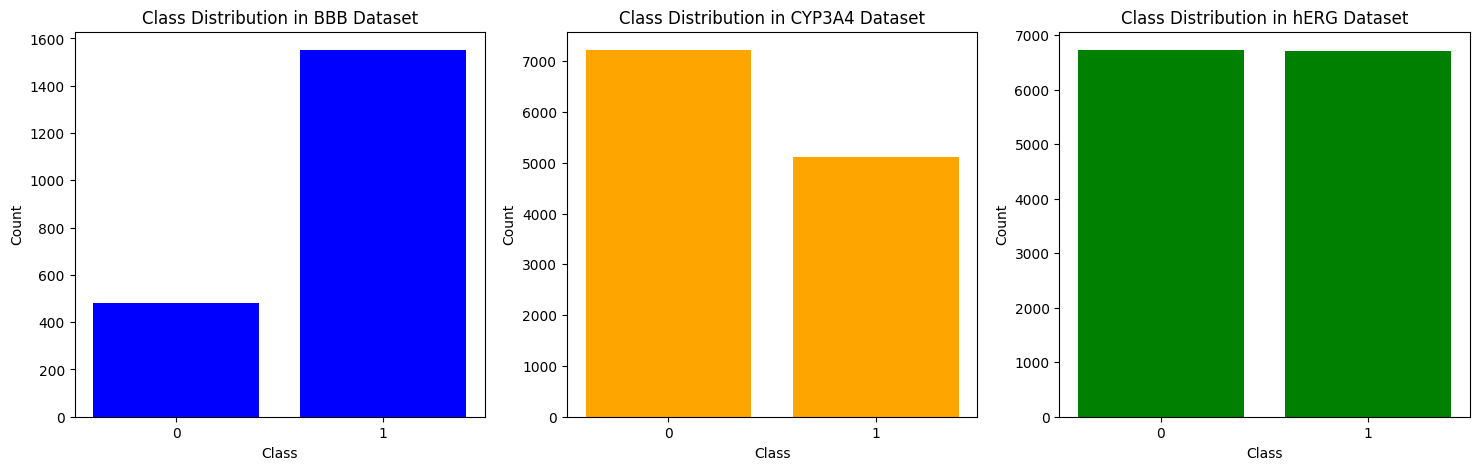

EDA - Visualizations --- Data Distributions (Regression Tasks)


None

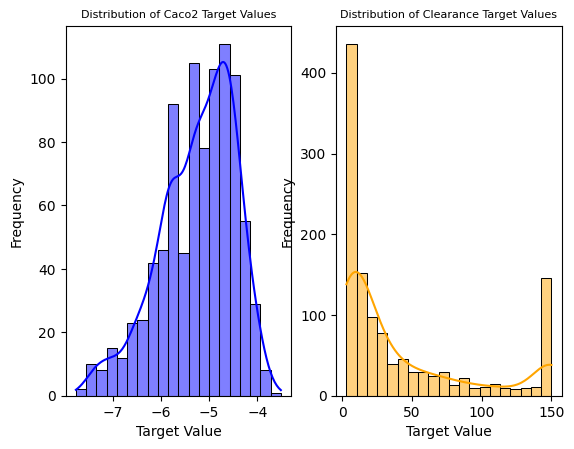

EDA Analysis Summary. No Missing values in any dataset (Smile/Drug or Target).


None

Class balance. BBB is imbalanced, 1:3 ratio -> Use AUROC and weighted BCE loss. CYP3A4 is slightly imbalanced, 1:1.5 ratio -> use BCE. hERG is balanced +/- 1:1 ratio. Use -> BCE.


None

Data distribution. Caco2 is almost normal distributed, Clearance is more right-skewed. Consider log transformation np.log1p() for Clearance dataset.


None

Remember to use standard scaling for regression tasks


None

In [4]:
# Build Dataframe and Exploratory Data Analysis (EDA) for each dataset

# Create DataFrames for ESOL dataset splits
display (print ("Caco2 Dataset - Summary Statistics and Information"))
display (df_caco2.head())
display (df_caco2.shape)
display (df_caco2.describe())
display (df_caco2.info())
display (df_caco2.isna().sum()) #Check for missing values in the "Drug" column


display (print ("BBB Dataset - Summary Statistics and Information"))
display (df_bbb.head())
display (df_bbb.shape)
display (df_bbb.describe())
display (df_bbb.info())
display (df_bbb.isna().sum()) #Check for missing values in the "Drug


display (print ("CYP3A4 Dataset - Summary Statistics and Information"))
display (df_cyp3a4.head())
display (df_cyp3a4.shape)
display (df_cyp3a4.describe())
display (df_cyp3a4.info())
display (df_cyp3a4.isna().sum()) #Check for missing values in
cyp3a4_na_drug_values = df_cyp3a4['Drug'].isna().sum()
cyp3a4_na_target_values = df_cyp3a4['Y'].isna().sum()


display (print ("Clearance Dataset - Summary Statistics and Information"))
display (df_clearance.head())
display (df_clearance.shape)
display (df_clearance.describe())
display (df_clearance.info())
display (df_clearance.isna().sum()) #Check for missing values in


display (print ("hERG Dataset - Summary Statistics and Information"))
display (df_herg.head())
display (df_herg.shape)
display (df_herg.describe())
display (df_herg.info())
display (df_herg.isna().sum()) #Check for missing values in




display (print ("EDA - Visualizations --- Class Balance Analysis (Classification Tasks)"))

# Class balance analysis - Classification datasets (BBB, CYP3A4 and hERG)
# Create 3 subplots for class distribution in each classification dataset
# 1Row and 3 Columns
plt.subplots (1, 3, figsize = (18, 5))
# 1row and 1st column - BBB Dataset
plt.subplot (1, 3, 1)
plt.bar (df_bbb["Y"].value_counts().index, df_bbb["Y"].value_counts().values, color = "blue")
plt.title ("Class Distribution in BBB Dataset")
plt.xlabel ("Class")
plt.ylabel ("Count")
plt.xticks (df_bbb["Y"].value_counts().index)


# 1row and 2nd column - CYP3A4 Dataset
plt.subplot (1, 3, 2)
plt.bar (df_cyp3a4["Y"].value_counts().index, df_cyp3a4["Y"].value_counts().values, color = "orange")
plt.title ("Class Distribution in CYP3A4 Dataset")
plt.xlabel ("Class")
plt.ylabel ("Count")
plt.xticks (df_cyp3a4["Y"].value_counts().index)
# 1row and 3rd column - hERG Dataset
plt.subplot (1, 3, 3)
plt.bar (df_herg["Y"].value_counts().index, df_herg["Y"].value_counts().values, color = "green")
plt.title ("Class Distribution in hERG Dataset")
plt.xlabel ("Class")
plt.ylabel ("Count")
plt.xticks (df_herg["Y"].value_counts().index)
plt.show()

display (print ("EDA - Visualizations --- Data Distributions (Regression Tasks)"))

plt.subplot(1, 2, 1)
sns.histplot(df_caco2["Y"], bins = 20, color = "blue", edgecolor = "black", kde=True)
plt.title ("Distribution of Caco2 Target Values", fontsize = 8)
plt.xlabel ("Target Value")
plt.ylabel ("Frequency")
#plt.show()
plt.subplot(1, 2, 2)
sns.histplot(df_clearance["Y"], bins = 20, color = "orange", edgecolor = "black", kde=True)
plt.title ("Distribution of Clearance Target Values", fontsize = 8)
plt.xlabel ("Target Value")
plt.ylabel ("Frequency")
plt.show()



display (print ("EDA Analysis Summary. No Missing values in any dataset (Smile/Drug or Target)."))
display (print ("Class balance. BBB is imbalanced, 1:3 ratio -> Use AUROC and weighted BCE loss. CYP3A4 is slightly imbalanced, 1:1.5 ratio -> use BCE. hERG is balanced +/- 1:1 ratio. Use -> BCE."))
display (print ("Data distribution. Caco2 is almost normal distributed, Clearance is more right-skewed. Consider log transformation np.log1p() for Clearance dataset."))
display (print ("Remember to use standard scaling for regression tasks"))



Merged Dataset - Summary Statistics and Information


None

,SMILES,Caco2,Clearance,BBB,Cyp3a4,Herg
0,Br.Brc1ccc(C2=Nn3c(nnc3-c3cccnc3)SC2)s1,NaN,NaN,NaN,1.0,NaN
1,Br.C/C(=N/NC1=NCCN1)c1cn(C2=NCCN2)nc1C,NaN,NaN,NaN,0.0,NaN
2,Br.CC(C)CC1CC(=O)OC1(C)C(=O)CSc1nc2ccccc2s1,NaN,NaN,NaN,1.0,NaN
3,Br.CC(NC1=NCCCCC1)c1ccccc1,NaN,NaN,NaN,0.0,NaN
4,Br.CCCCCCN1Cc2ccccc2C1,NaN,NaN,NaN,0.0,NaN
5,Br.CCCCN1C2=NCCCN2c2ccccc21,NaN,NaN,NaN,0.0,NaN
6,Br.CCOc1ccc2c(c1)nc(SCC(=O)c1ccc(Br)s1)n2C,NaN,NaN,NaN,1.0,NaN
7,Br.CC[C@H]1CN2CC[C@@H]1C[C@H]2[C@@H](O)c1ccnc2...,NaN,NaN,NaN,0.0,NaN
8,Br.COC(=O)Cn1c(=N)n(CCN2CCCCC2)c2ccccc21,NaN,NaN,NaN,0.0,NaN
9,Br.COCC(C)NCc1cccc(C)c1,NaN,NaN,NaN,0.0,NaN


(29264, 6)

Merge Dataset - Visualization


None

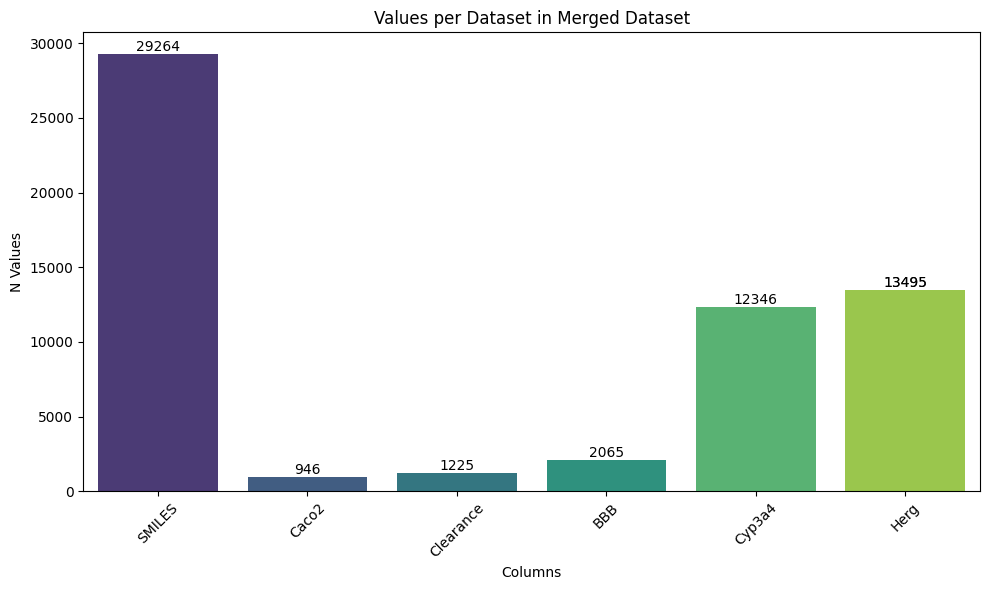

Regression Dataset - summary


None

,Caco2,Clearance
count,930.000000,1213.000000
mean,-5.231624,42.900371
std,0.775019,49.847322
min,-7.760000,3.000000
25%,-5.760762,6.000000
50%,-5.118076,19.000000
75%,-4.631556,64.000000
max,-3.510000,150.000000


,SMILES,Caco2,Clearance
0,C#CC#CC/C=C\CCCCC/C=C/C(=O)NCC(C)CC,-4.430000,NaN
1,C#CC#CC/C=C\CCCCCC(C)=O,-4.492425,NaN
2,C#CC[C@@H](C(=O)N[C@H](/C=C/C(=O)OCC)C[C@@H]1C...,NaN,38.02
3,C#CC[C@@H](C(=O)N[C@H](/C=C/C(=O)OCC)C[C@@H]1C...,NaN,150.00
4,C#C[C@@]1(O)CC[C@@H]2[C@H]3CCC4=Cc5oncc5C[C@@]...,-4.561461,NaN
5,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,-4.840000,NaN
6,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,-4.470000,9.77
7,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,-4.470000,7.41
8,C#Cc1cccc(Nc2ncnc3cc4c(cc23)OCCOCCOCCO4)c1,NaN,3.55
9,C#Cc1cccc(Nc2ncnc3cc4c(cc23)OCCOCCOCCO4)c1,NaN,21.88


(2079, 3)

Classification Dataset - summary


None

,BBB,Cyp3a4,Herg
count,2030.000000,12334.000000,13463.000000
mean,0.764039,0.414464,0.499517
std,0.424702,0.492649,0.500018
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


,SMILES,BBB,Cyp3a4,Herg
0,Br.Brc1ccc(C2=Nn3c(nnc3-c3cccnc3)SC2)s1,NaN,1.0,NaN
1,Br.C/C(=N/NC1=NCCN1)c1cn(C2=NCCN2)nc1C,NaN,0.0,NaN
2,Br.CC(C)CC1CC(=O)OC1(C)C(=O)CSc1nc2ccccc2s1,NaN,1.0,NaN
3,Br.CC(NC1=NCCCCC1)c1ccccc1,NaN,0.0,NaN
4,Br.CCCCCCN1Cc2ccccc2C1,NaN,0.0,NaN
5,Br.CCCCN1C2=NCCCN2c2ccccc21,NaN,0.0,NaN
6,Br.CCOc1ccc2c(c1)nc(SCC(=O)c1ccc(Br)s1)n2C,NaN,1.0,NaN
7,Br.CC[C@H]1CN2CC[C@@H]1C[C@H]2[C@@H](O)c1ccnc2...,NaN,0.0,NaN
8,Br.COC(=O)Cn1c(=N)n(CCN2CCCCC2)c2ccccc21,NaN,0.0,NaN
9,Br.COCC(C)NCc1cccc(C)c1,NaN,0.0,NaN


(27526, 4)

In [5]:
# Merge datasets and additional EDA.

#RENAME COLUMNS
df_caco2.rename(columns = {"Drug": "SMILES", "Y": "Caco2"}, inplace = True)
df_clearance.rename(columns = {"Drug": "SMILES", "Y": "Clearance"}, inplace = True)
df_bbb.rename(columns = {"Drug": "SMILES", "Y": "BBB"}, inplace = True)
df_cyp3a4.rename(columns = {"Drug": "SMILES", "Y": "Cyp3a4"}, inplace = True)
df_herg.rename(columns = {"Drug": "SMILES", "Y": "Herg"}, inplace = True)

# Merge datasets on "SMILES" column using outer join to retain all compounds
# Regression datasets - Caco2 and Clearance
df_regression = df_caco2[["SMILES", "Caco2"]].merge(df_clearance[["SMILES", "Clearance"]], on="SMILES", how = "outer")
# Classification datasets - BBB, CYP3A4 and hERG
df_classification = df_bbb[["SMILES", "BBB"]].merge(df_cyp3a4[["SMILES", "Cyp3a4"]], on="SMILES", how = "outer").merge(df_herg[["SMILES", "Herg"]], on = "SMILES", how = "outer")

# Final merged dataset with all tasks
df_merged = df_regression.merge(df_classification, on = "SMILES", how = "outer")

display (print ("Merged Dataset - Summary Statistics and Information"))
display (df_merged.head(10))
display (df_merged.shape)
#Visualization_count_merged_dataframe
display (print ("Merge Dataset - Visualization"))
fig, ax = plt.subplots(figsize = (10, 6))
sns.barplot(x = df_merged.notna().sum().index, y = df_merged.notna().sum().values, palette = "viridis")
for container in ax.containers:
    ax.bar_label(container, fmt = "%d", label_type = "edge")
ax.bar_label(container, fmt = "%d", label_type = "edge")
plt.title ("Values per Dataset in Merged Dataset")
plt.xlabel ("Columns")
plt.ylabel ("N Values")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()




# Separate regression and classification datasets for modeling
# Regression
display (print ("Regression Dataset - summary"))
display (df_regression.describe())
display (df_regression.head(10))
display (df_regression.shape)
# Classification
display (print ("Classification Dataset - summary"))
display (df_classification.describe())
display (df_classification.head(10))
display (df_classification.shape)



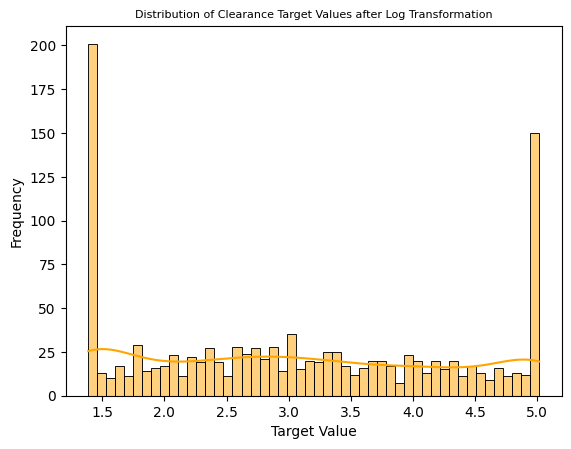

In [6]:
df_regression["Clearance"] = np.log1p(df_regression["Clearance"])

plt.subplot(1,1,1)
sns.histplot(df_regression["Clearance"], bins = 50, color = "orange", edgecolor = "black", kde=True)
plt.title ("Distribution of Clearance Target Values after Log Transformation", fontsize = 8)
plt.xlabel ("Target Value")
plt.ylabel ("Frequency")
plt.show()

# The distribution is +/- bimodal.
# This is expected as the dataset contains clearance data, anda biological dataset of clearence
# ...tends to have a mix of low and high clearance compounds, leading to a bimodal distribution.

In [7]:
#Next step - cannonicalize SMILES for each dataset.

def canonicalize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    Chem.RemoveStereochemistry(mol) #Remove stereochemistry to avoid issues with canonicalization
    return Chem.MolToSmiles(mol, canonical=True)

# Get cannonical SMILES and drop rows with invalid SMILES after caonicalization process.
# Canonicalizing a list of SMILES means converting them to a standard form...
# ...which helps to esure that different representations of the same molecule are treated as the same, and also helps to remove any invalid SMILES that cannot be parsed by RDKit. 
# After canonicalization, we drop any rows with invalid SMILES (those that could not be parsed) to ensure data quality for modeling.
df_regression["SMILES"] = df_regression["SMILES"].apply(canonicalize_smiles)
df_regression.dropna(subset=["SMILES"], inplace = True) #Drop rows with invalid SMILES
df_classification["SMILES"] = df_classification["SMILES"].apply(canonicalize_smiles)
df_classification.dropna(subset=["SMILES"], inplace = True) #Drop rows with invalid SMILES




[16:14:31] WARNING: not removing hydrogen atom without neighbors
[16:14:31] WARNING: not removing hydrogen atom without neighbors
[16:14:31] WARNING: not removing hydrogen atom without neighbors
[16:14:31] WARNING: not removing hydrogen atom without neighbors
[16:14:31] WARNING: not removing hydrogen atom without neighbors
[16:14:31] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not removing hydrogen atom without neighbors
[16:14:32] WARNING: not r

In [8]:
# Calculate additional molecular descriptors using rdkit.

def get_mol_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "MolWeight" : Descriptors.MolWt(mol),
        "LogP" : Descriptors.MolLogP(mol),
        "TPSA" : Descriptors.TPSA(mol),
        "HBD" : Descriptors.NumHDonors(mol),
        "HBA" : Descriptors.NumHAcceptors(mol),
        "RotatableBonds" : Descriptors.NumRotatableBonds(mol),
        "Ring Count" : Descriptors.RingCount(mol),
        "FractionCSP3" : Descriptors.FractionCSP3(mol),
        "Formal charge" : Chem.GetFormalCharge(mol),
    }
    
# Calculate descriptors for regression and classification datasets and concatenate them to the original dataframe.
# Regression
regression_descriptors = df_regression["SMILES"].apply(get_mol_descriptors)
df_regression = pd.concat([df_regression, regression_descriptors.apply(pd.Series)], axis = 1)
display (print (df_regression.head(5)))
# Classification
classification_descriptors = df_classification["SMILES"].apply(get_mol_descriptors)
df_classification = pd.concat([df_classification, classification_descriptors.apply(pd.Series)], axis = 1)
display (print (df_classification.head(5)))


                                              SMILES     Caco2  Clearance  \
0                    C#CC#CCC=CCCCCCC=CC(=O)NCC(C)CC -4.430000        NaN   
1                              C#CC#CCC=CCCCCCC(C)=O -4.492425        NaN   
2  C#CCC(C(=O)NC(C=CC(=O)OCC)CC1CCNC1=O)n1cccc(NC...       NaN   3.664074   
3  C#CCC(C(=O)NC(C=CC(=O)OCC)CC1CCNC1=O)n1cccc(NC...       NaN   5.017280   
4          C#CC1(O)CCC2C3CCC4=Cc5oncc5CC4(C)C3CCC21C -4.561461        NaN   

   MolWeight     LogP    TPSA  HBD  HBA  RotatableBonds  Ring Count  \
0    299.458  4.23830   29.10  1.0  1.0            11.0         0.0   
1    202.297  3.10880   17.07  0.0  1.0             7.0         0.0   
2    523.546  1.09172  161.63  3.0  8.0            11.0         3.0   
3    523.546  1.09172  161.63  3.0  8.0            11.0         3.0   
4    337.463  4.22100   46.26  1.0  3.0             0.0         5.0   

   FractionCSP3  Formal charge  
0      0.550000            0.0  
1      0.500000            0.0  
2      0.38

None

[16:14:55] WARNING: not removing hydrogen atom without neighbors
[16:14:55] WARNING: not removing hydrogen atom without neighbors
[16:14:56] WARNING: not removing hydrogen atom without neighbors
[16:14:56] WARNING: not removing hydrogen atom without neighbors
[16:14:57] WARNING: not removing hydrogen atom without neighbors
[16:14:57] WARNING: not removing hydrogen atom without neighbors
[16:14:58] WARNING: not removing hydrogen atom without neighbors
[16:14:58] WARNING: not removing hydrogen atom without neighbors
[16:14:58] WARNING: not removing hydrogen atom without neighbors
[16:14:58] WARNING: not removing hydrogen atom without neighbors
[16:14:58] WARNING: not removing hydrogen atom without neighbors
[16:14:58] WARNING: not removing hydrogen atom without neighbors
[16:14:58] WARNING: not removing hydrogen atom without neighbors
[16:14:58] WARNING: not removing hydrogen atom without neighbors
[16:14:59] WARNING: not removing hydrogen atom without neighbors
[16:14:59] WARNING: not r

                                        SMILES  BBB  Cyp3a4  Herg  MolWeight  \
0      Br.Brc1ccc(C2=Nn3c(nnc3-c3cccnc3)SC2)s1  NaN     1.0   NaN    459.192   
1         Br.CC(=NNC1=NCCN1)c1cn(C2=NCCN2)nc1C  NaN     0.0   NaN    355.244   
2  Br.CC(C)CC1CC(=O)OC1(C)C(=O)CSc1nc2ccccc2s1  NaN     1.0   NaN    444.416   
3                   Br.CC(NC1=NCCCCC1)c1ccccc1  NaN     0.0   NaN    297.240   
4                       Br.CCCCCCN1Cc2ccccc2C1  NaN     0.0   NaN    284.241   

      LogP   TPSA  HBD  HBA  RotatableBonds  Ring Count  FractionCSP3  \
0  4.10010  55.96  0.0  6.0             2.0         4.0      0.076923   
1 -0.15048  90.99  3.0  7.0             2.0         3.0      0.500000   
2  4.90330  56.26  0.0  6.0             6.0         3.0      0.500000   
3  3.88760  24.39  1.0  2.0             2.0         2.0      0.500000   
4  4.16040   3.24  0.0  1.0             5.0         2.0      0.571429   

   Formal charge  
0            0.0  
1            0.0  
2            0.0  
3   

None

In [9]:
# Next step is to build Molecule Data points.

#PREPARE DATA FOR MODELING
descriptor_cols = ["MolWeight", "LogP", "TPSA", "HBD", "HBA", "RotatableBonds", "Ring Count", "FractionCSP3", "Formal charge"]
regression_target_cols = ["Caco2", "Clearance"]
classification_target_cols = ["BBB", "Cyp3a4", "Herg"]

# Get regressiondatapoints for regression dataset
regression_datapoints = [
    cp.data.MoleculeDatapoint(
        mol=Chem.MolFromSmiles(smiles),
        y=targets,
        x_d=desc
    )
    for smiles, targets, desc in zip(
        df_regression["SMILES"],
        df_regression[regression_target_cols].values.astype(float),
        df_regression[descriptor_cols].values.astype(float)
    )
]

# Get classification datapoints for classification dataset
classification_datapoints = [
    cp.data.MoleculeDatapoint(
        mol=Chem.MolFromSmiles(smiles),
        y=targets,
        x_d=desc
    )
    for smiles, targets, desc in zip(
        df_classification["SMILES"],
        df_classification[classification_target_cols].values.astype(float),
        df_classification[descriptor_cols].values.astype(float)
    )
]


[16:16:01] WARNING: not removing hydrogen atom without neighbors
[16:16:01] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not removing hydrogen atom without neighbors
[16:16:02] WARNING: not r

In [10]:
# Scaffold balance splits - Regression dataset

# Build reg_mol objects for regression dataset using rdkit
reg_mols = [Chem.MolFromSmiles(smiles) for smiles in df_regression["SMILES"]]

# Make scaffold balanced indices for regression dataset
# Docs: https://chemprop.readthedocs.io/en/main/autoapi/chemprop/data/index.html#chemprop.data.make_split_indices
reg_train_idx, reg_val_idx, reg_test_idx = cp.data.make_split_indices(
    mols = reg_mols,
    split = "scaffold_balanced",
    sizes = (0.8, 0.1, 0.1),
    seed = 42,
    num_replicates=1,
)
# Aplly the splits to the regression dataset
# docs: https://chemprop.readthedocs.io/en/main/autoapi/chemprop/data/index.html#chemprop.data.split_data_by_indices
splits_reg = cp.data.split_data_by_indices(
    data = regression_datapoints,
    train_indices = reg_train_idx,
    val_indices = reg_val_idx,
    test_indices = reg_test_idx,
)
# Data featuarizer step to feed the MPNN model.
# docs: https://chemprop.readthedocs.io/en/main/autoapi/chemprop/data/index.html#chemprop.data.MoleculeDataset
# Can also be done using the data DataLoader module.
reg_train = cp.data.MoleculeDataset(splits_reg[0][0])
reg_val = cp.data.MoleculeDataset(splits_reg[1][0])
reg_test = cp.data.MoleculeDataset(splits_reg[2][0])

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)


In [11]:
# Build cls_mol objects for classification dataset using rdkit
cls_mols = [Chem.MolFromSmiles(smiles) for smiles in df_classification["SMILES"]]

# Make scaffold balanced indices for classification dataset
# Docs: https://chemprop.readthedocs.io/en/main/autoapi/chemprop/data/index.html#chemprop.data.make_split_indices
cls_train_idx, cls_val_idx, cls_test_idx = cp.data.make_split_indices(
    mols = cls_mols,
    split = "scaffold_balanced",
    sizes = (0.8, 0.1, 0.1),
    seed = 42,
    num_replicates=1,
)
# Aplly the splits to the classification dataset
# docs: https://chemprop.readthedocs.io/en/main/autoapi/chemprop/data/index.html#chemprop.data.split_data_by_indices
split_cls = cp.data.split_data_by_indices(
    data = classification_datapoints,
    train_indices = cls_train_idx,
    val_indices = cls_val_idx,
    test_indices = cls_test_idx,
)
# Data featuarizer step to feed the MPNN model.
# docs: https://chemprop.readthedocs.io/en/main/autoapi/chemprop/data/index.html#chemprop.data.MoleculeDataset
# Can also be done using the data DataLoader module.
cls_train = cp.data.MoleculeDataset(split_cls[0][0])
cls_val = cp.data.MoleculeDataset(split_cls[1][0])
cls_test = cp.data.MoleculeDataset(split_cls[2][0])

[16:16:20] WARNING: not removing hydrogen atom without neighbors
[16:16:20] WARNING: not removing hydrogen atom without neighbors
[16:16:20] WARNING: not removing hydrogen atom without neighbors
[16:16:20] WARNING: not removing hydrogen atom without neighbors
[16:16:20] WARNING: not removing hydrogen atom without neighbors
[16:16:20] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not removing hydrogen atom without neighbors
[16:16:21] WARNING: not r

In [12]:
# Next step scalling - targets for regression tasks only.
# Note: Classification Targets are binary (0 or 1). Does not need scaling.
# Note2: The scaler is applied directly to the dataset, inplace.
# Docs - https://chemprop.readthedocs.io/en/main/tutorial/python/scaling.html
# Targets are already identified as "y" above in the MoleculeDatapoint definitiion.
output_scaler_reg = reg_train.normalize_targets()
reg_val.normalize_targets(output_scaler_reg)
#print ("Scaler mean reg target:" , output_scaler_reg.mean_, "Scaler scale reg target:" , output_scaler_reg.scale_)
# reg_test target is not scaled to prevent data leakage.
# Insted we will use the output_scaler_reg to make an UnscaleTransform which is given to the predictor (FFN) layer and used automatically during inference.


#Scale regression descriptors (x_d)
X_d_scaler_reg = reg_train.normalize_inputs("X_d")
reg_val.normalize_inputs("X_d", X_d_scaler_reg)
reg_test.normalize_inputs("X_d", X_d_scaler_reg)
#print ("Scaler mean descriptors:" , X_d_scaler_reg.mean_, "Scaler scale descriptors:" , X_d_scaler_reg.scale_)

#colect all 9 descriptors into a numpy array to check if they are scaled correctly.
train_xd_reg = np.array([dp.x_d for dp in reg_train])
# After scaling, the mean of each descriptor should be close to 0 and the standard deviation should be close to 1.
# We use np.allclose to check if the mean is close to 0 within a tolerance of 0.01 and if the standard deviation is close to 1 within a tolerance of 0.05. 
# If both conditions are met, we print "Scaling OK". 
# If not, an assertion error will be raised indicating that the descriptors are not properly scaled.
assert np.allclose(train_xd_reg.mean(axis=0), 0, atol=0.01), "x_d not centered"
assert np.allclose(train_xd_reg.std(axis=0),  1, atol=0.05), "x_d not scaled"
print("Scaling OK")

Scaling OK


In [13]:
#Scale classification descriptors (x_d)
X_d_scaler_cls = cls_train.normalize_inputs("X_d")
cls_val.normalize_inputs("X_d", X_d_scaler_cls)
cls_test.normalize_inputs("X_d", X_d_scaler_cls)

#colect all 9 descriptors into a numpy array to check if they are scaled correctly.
train_xd_cls = np.array([dp.x_d for dp in cls_train])
# After scaling, the mean of each descriptor should be close to 0 and the standard deviation should be close to 1.
# We use np.allclose to check if the mean is close to 0 within a tolerance of 0.01 and if the standard deviation is close to 1 within a tolerance of 0.05. 
# If both conditions are met, we print "Scaling OK". 
# If not, an assertion error will be raised indicating that the descriptors are not properly scaled.
assert np.allclose(train_xd_cls.mean(axis=0), 0, atol=0.01), "x_d not centered"
assert np.allclose(train_xd_cls.std(axis=0),  1, atol=0.05), "x_d not scaled"
print("Scaling OK")

Scaling OK


In [14]:
# Build Data Loaders for regression and classification datasets.
# This is built in chemprop that uses PyTorch DataLoaders under the hood.
# The DataLoader is responsible for batching the data and feeding it to the model during training and evaluation.
# Docs: https://chemprop.readthedocs.io/en/main/tutorial/python/data/dataloaders.html


# Build DataLoaders
# shuffle=True for train (randomizes batch order each epoch), False for val/test
reg_train_loader = cp.data.build_dataloader(reg_train, batch_size=64, shuffle=True,  num_workers=0)
reg_val_loader   = cp.data.build_dataloader(reg_val,   batch_size=64, shuffle=False, num_workers=0)
reg_test_loader  = cp.data.build_dataloader(reg_test,  batch_size=64, shuffle=False, num_workers=0)
# shuffle=True for train (randomizes batch order each epoch), False for val/test
cls_train_loader = cp.data.build_dataloader(cls_train, batch_size=64, shuffle=True,  num_workers=0)
cls_val_loader   = cp.data.build_dataloader(cls_val,   batch_size=64, shuffle=False, num_workers=0)
cls_test_loader  = cp.data.build_dataloader(cls_test,  batch_size=64, shuffle=False, num_workers=0)

# Print number of batches in each dataloader
# Sanity check to ensure that the dataloaders are correctly built and contain the expected number of batches based on the dataset sizes and batch size.
print(f"Reg  — train: {len(reg_train_loader)} batches | val: {len(reg_val_loader)} | test: {len(reg_test_loader)}")
print(f"Cls  — train: {len(cls_train_loader)} batches | val: {len(cls_val_loader)} | test: {len(cls_test_loader)}")

Dropping last batch of size 1 to avoid issues with batch normalization     (dataset size = 1665, batch_size = 64)


Reg  — train: 26 batches | val: 4 | test: 4
Cls  — train: 345 batches | val: 43 | test: 43


In [14]:
# Check the structure of a batch from the regression train dataloader before building the model and training loop.
# This is a sanity check to understand the structure of the data that will be fed into the model during training.
#batch = next(iter(reg_train_loader))
#print (type(batch), len(batch)) #  <class 'chemprop.data.collate.TrainingBatch'> 7
#print(batch._fields)  # TrainingBatch is a namedtuple — this shows all field names -> ('bmg', 'V_d', 'X_d', 'Y', 'w', 'lt_mask', 'gt_mask')

# Check shapes of each field in the batch
#bmg, V_d, X_d, Y, w, lt_mask, gt_mask = batch
# Batch size = 64
#print(f"X_d:     {X_d.shape}")    # [batch_size, 9]
#print(f"Y:       {Y.shape}")      # [batch_size, 2]  (Caco2, Clearance)
#print(f"V_d:     {V_d}")          # likely None since we didn't set atom-level features
#print(f"w:       {w.shape}")      # [batch_size, 1]

In [ ]:
# Class definition for the multi-task ADMET model using PyTorch Lightning and Chemprop's MPNN architecture.
# Chemprop Documentation
# DOCS: https://chemprop.readthedocs.io/en/main/tutorial/python/models/message_passing.html#multi-task-models
# Docs: https://chemprop.readthedocs.io/en/main/tutorial/python/data/dataloaders.html

# LightningModule Pytorch Documentation:
# Docs: https://lightning.ai/docs/pytorch/stable/starter/introduction.html
class MultiTaskADMETModel(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.message_passing = BondMessagePassing(
            d_h = 300,
            bias = False,
            depth = 3,
            undirected = False,
            dropout = 0.0,
            activation = "relu"
        )
        self.agg = MeanAggregation()

        unscale = UnscaleTransform.from_standard_scaler(output_scaler_reg)
        
        self.regression_head = RegressionFFN(
            input_dim=309, 
            n_tasks=2,
            n_layers = 1,
            hidden_dim = 300,
            dropout = 0.0,
            activation = "relu",
            criterion = None,
            task_weights = None,
            output_transform=unscale)
        
        self.classification_head = BinaryClassificationFFN(
            input_dim=309, 
            n_tasks=3,
            n_layers = 1,
            hidden_dim = 300,
            dropout = 0.0,
            activation = "relu",
            criterion = None,
            task_weights = None,
            )
        
        self.lr = lr

        self.val_mse_caco2      = MeanSquaredError()
        self.val_mae_caco2      = MeanAbsoluteError()
        self.val_mse_clearance  = MeanSquaredError()
        self.val_mae_clearance  = MeanAbsoluteError()

        self.val_auroc_bbb      = BinaryAUROC()
        self.val_auroc_cyp3a4   = BinaryAUROC()
        self.val_auroc_herg     = BinaryAUROC()

    def encode(self, bmg, X_d):
        H       = self.message_passing(bmg)
        mol_vec = self.agg(H, bmg.batch)
        return torch.cat([mol_vec, X_d], dim=-1)

    def _masked_loss(self, preds, Y, loss_fn):
        mask = ~torch.isnan(Y)
        return loss_fn(preds[mask], Y.nan_to_num()[mask])

    def training_step(self, batch, batch_idx):
        if isinstance(batch, tuple):
            batch = batch[0]
        losses = []
        if batch.get("regression") is not None:
            bmg, V_d, X_d, Y, w, lt_mask, gt_mask = batch["regression"]
            preds = self.regression_head(self.encode(bmg, X_d))
            losses.append(self._masked_loss(preds, Y, F.mse_loss))

        if batch.get("classification") is not None:
            bmg, V_d, X_d, Y, w, lt_mask, gt_mask = batch["classification"]
            preds = self.classification_head(self.encode(bmg, X_d))
            losses.append(self._masked_loss(preds, Y, F.binary_cross_entropy_with_logits))
        total = sum(losses)
        self.log("train/loss", total, prog_bar=True)
        return total

    def validation_step(self, batch, batch_idx):
        if isinstance(batch, tuple):
            batch = batch[0]
        if batch.get("regression") is not None:
            bmg, V_d, X_d, Y, w, lt_mask, gt_mask = batch["regression"]
            preds = self.regression_head(self.encode(bmg, X_d))

            # Unscale Y to match preds: UnscaleTransform is applied to preds in eval mode,
            # so Y (stored scaled) must be inverse-transformed to the same original scale.
            Y_unscaled = Y.numpy().copy()
            nan_mask = np.isnan(Y_unscaled)
            Y_unscaled[nan_mask] = 0
            Y_unscaled = output_scaler_reg.inverse_transform(Y_unscaled)
            Y_unscaled[nan_mask] = np.nan
            Y_unscaled = torch.tensor(Y_unscaled, dtype=torch.float32)

            # on_step=False, on_epoch=True: epoch-average avoids sawtooth from cycling loader
            self.log("val/reg_loss", self._masked_loss(preds, Y_unscaled, F.mse_loss),
                     prog_bar=True, on_step=False, on_epoch=True)

            for i, (mse_m, mae_m) in enumerate([(self.val_mse_caco2, self.val_mae_caco2),
                                                 (self.val_mse_clearance, self.val_mae_clearance)]):
                mask = ~torch.isnan(Y_unscaled[:, i])
                if mask.any():
                    mse_m.update(preds[mask, i], Y_unscaled[mask, i])
                    mae_m.update(preds[mask, i], Y_unscaled[mask, i])

        if batch.get("classification") is not None:
            bmg, V_d, X_d, Y, w, lt_mask, gt_mask = batch["classification"]
            probs = self.classification_head(self.encode(bmg, X_d))
            self.log("val/cls_loss", self._masked_loss(probs, Y, F.binary_cross_entropy_with_logits), prog_bar=True)
            for i, auroc_m in enumerate([self.val_auroc_bbb, self.val_auroc_cyp3a4, self.val_auroc_herg]):
                mask = ~torch.isnan(Y[:, i])
                if mask.any():
                    auroc_m.update(probs[mask, i], Y[mask, i].long())

    def on_validation_epoch_end(self):
        self.log("val/rmse_caco2",     self.val_mse_caco2.compute().sqrt())
        self.log("val/mae_caco2",      self.val_mae_caco2.compute())
        self.log("val/rmse_clearance", self.val_mse_clearance.compute().sqrt())
        self.log("val/mae_clearance",  self.val_mae_clearance.compute())
        self.log("val/auroc_bbb",      self.val_auroc_bbb.compute(),    prog_bar=True)
        self.log("val/auroc_cyp3a4",   self.val_auroc_cyp3a4.compute(), prog_bar=True)
        self.log("val/auroc_herg",     self.val_auroc_herg.compute(),   prog_bar=True)
        for m in [self.val_mse_caco2, self.val_mae_caco2,
                  self.val_mse_clearance, self.val_mae_clearance,
                  self.val_auroc_bbb, self.val_auroc_cyp3a4, self.val_auroc_herg]:
            m.reset()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [16]:
# CombinedLoader + instantiation of the model.
# The CombinedLoader is used to combine the regression and classification dataloaders into a single dataloader that can be fed into the multi-task model during training and validation.
# The mode "max_size_cycle" ensures that the loader will cycle through the smaller dataset until the larger one is exhausted, allowing for balanced training across both tasks even if the datasets have different sizes.
# Docs: https://pytorch-lightning.readthedocs.io/en/stable/data/combine_loaders.html#combinedloader
combined_train = CombinedLoader(
    {"regression": reg_train_loader, "classification": cls_train_loader},
    mode="max_size_cycle"
)
combined_val = CombinedLoader(
    {"regression": reg_val_loader, "classification": cls_val_loader},
    mode="max_size_cycle"
)

In [17]:
# Instantiate model
model = MultiTaskADMETModel(lr=1e-3)
print(model)

MultiTaskADMETModel(
  (message_passing): BondMessagePassing(
    (W_i): Linear(in_features=86, out_features=300, bias=False)
    (W_h): Linear(in_features=300, out_features=300, bias=False)
    (W_o): Linear(in_features=372, out_features=300, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
    (tau): ReLU()
    (V_d_transform): Identity()
    (graph_transform): Identity()
  )
  (agg): MeanAggregation()
  (regression_head): RegressionFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=309, out_features=300, bias=True)
      )
      (1): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.0, inplace=False)
        (2): Linear(in_features=300, out_features=2, bias=True)
      )
    )
    (criterion): MSE(task_weights=[[1.0, 1.0]])
    (output_transform): UnscaleTransform()
  )
  (classification_head): BinaryClassificationFFN(
    (ffn): MLP(
      (0): Sequential(
        (0): Linear(in_features=309, out_features=300, bias=True)
      )
      (1): Seq

In [18]:
# Use CSVLogger to save logs to a CSV file in the "logs" dire.
# This allows us to track the training and validation losses for both regression and classification tasks over epochs, and we can later analyze these logs to evaluate model performance and make decisions about hyperparameter tuning or early stopping.
# Docs: https://lightning.ai/docs/pytorch/stable/api_references.html#loggers
logger = CSVLogger(save_dir="logs", name="multi_task_admet")

In [19]:
# Sanity check - Check the structure of a batch from the combined dataloader before building the training loop.
"""
for batch in combined_train:
    print(type(batch))
    if isinstance(batch, dict):
        print("keys:", batch.keys())
    else:
        print("content:", type(batch[0]), type(batch[1]) if len(batch) > 1 else "")
    break

"""

'\nfor batch in combined_train:\n    print(type(batch))\n    if isinstance(batch, dict):\n        print("keys:", batch.keys())\n    else:\n        print("content:", type(batch[0]), type(batch[1]) if len(batch) > 1 else "")\n    break\n\n'

In [20]:
# Train the model using PyTorch Lightning's Trainer with the combined dataloaders and the CSVLogger for logging.
# The trainer will handle the training loop, validation loop, and logging of metrics as defined in
# Documentation : https://lightning.ai/docs/pytorch/stable/common/trainer.html

# build the trained
trainer = pl.Trainer(
    max_epochs=50,
    accelerator = "auto",
    logger = logger,
    enable_progress_bar=True,)

#Fit the model
trainer.fit(model, combined_train, combined_val)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ message_passing     │ BondMessagePassing      │  227 K │ train │     0 │
│ 1  │ agg                 │ MeanAggregation         │      0 │ train │     0 │
│ 2  │ regression_head     │ RegressionFFN           │ 93.6 K │ train │     0 │
│ 3  │ classification_head │ BinaryClassificationFFN │ 93.9 K │ train │     0 │
│ 4  │ val_mse_caco2       │ MeanSquaredError        │      0 │ train │     0 │
│ 5  │ val_mae_caco2       │ MeanAbsoluteError       │      0 │ train │     0 │
│ 6  │ val_mse_clearance   │ MeanSquaredError        │      0 │ train │     0 │
│ 7  │ val_mae_clearance   │ MeanAbsoluteError       │      0 │ train │     0 │
│ 8  │ val_auroc_bbb       │ BinaryAUROC             │      0 │ train │     0 │
│ 9  │ val_auroc_cyp3a4    │ BinaryAUROC             │      0 │ train │     0 │
│ 10 │ val_auroc_herg      │ BinaryAUROC             │      0 │ train │     0 │
└────┴─────────────────────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 415 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 415 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 36                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=50` reached.


In [19]:
# Docs: https://lightning.ai/docs/pytorch/stable/deploy/production_basic.html
# Docs: https://lightning.ai/docs/pytorch/stable/common/checkpointing_basic.html#lightningmodule-from-checkpoint

CKPT_PATH = "logs/multi_task_admet/version_1/checkpoints/epoch=49-step=17250.ckpt"

# Build Model Structure
model = MultiTaskADMETModel(lr=1e-3)
# Load model weights from checkpoint
checkpoint = torch.load(CKPT_PATH, map_location="cpu")
# Read the state_dict from the checkpoint and load it into the model. 
model.load_state_dict(checkpoint["state_dict"])
# Set the model to evaluation mode for inference / evaluation.
model.eval()
print("Model loaded from checkpoint.")

Model loaded from checkpoint.


In [20]:
# Check model performance metrics on the test set for both regression and classification tasks.

# --- Regression: Caco2 + Clearance ---
all_preds_reg, all_targets_reg = [], []

with torch.no_grad():
    for batch in reg_test_loader:
        bmg, V_d, X_d, Y, w, lt_mask, gt_mask = batch
        preds = model.regression_head(model.encode(bmg, X_d))  # UnscaleTransform applied automatically
        all_preds_reg.append(preds.numpy())
        all_targets_reg.append(Y.numpy())

preds_reg   = np.concatenate(all_preds_reg,   axis=0)  # [n_test, 2]
targets_reg = np.concatenate(all_targets_reg, axis=0)  # [n_test, 2]

print("=== Regression ===")
for i, task in enumerate(regression_target_cols):
    mask = ~np.isnan(targets_reg[:, i])
    rmse = np.sqrt(mean_squared_error(targets_reg[mask, i], preds_reg[mask, i]))
    mae  = mean_absolute_error(targets_reg[mask, i], preds_reg[mask, i])
    print(f"{task}: RMSE={rmse:.4f}  MAE={mae:.4f}")

# --- Classification: BBB + CYP3A4 + hERG ---
all_probs_cls, all_targets_cls = [], []

with torch.no_grad():
    for batch in cls_test_loader:
        bmg, V_d, X_d, Y, w, lt_mask, gt_mask = batch
        probs = model.classification_head(model.encode(bmg, X_d))  # sigmoid applied in eval mode
        all_probs_cls.append(probs.numpy())
        all_targets_cls.append(Y.numpy())

probs_cls   = np.concatenate(all_probs_cls,   axis=0)  # [n_test, 3]
targets_cls = np.concatenate(all_targets_cls, axis=0)  # [n_test, 3]

print("\n=== Classification ===")
for i, task in enumerate(classification_target_cols):
    mask = ~np.isnan(targets_cls[:, i])
    auroc = roc_auc_score(targets_cls[mask, i], probs_cls[mask, i])
    print(f"{task}: AUROC={auroc:.4f}")
    
    
# Discussion of results

"""
Classification (AUROC)

BBB	    0.856	Good
CYP3A4	0.894	Very good
hERG	0.846	Good

Published ADMET models on these same TDC benchmarks typically score 0.80-0.92

Regression (RMSE)

Caco2 - rmse	    0.4885	Good — target range is ~5 log units wide, so 0.4885 error is reasonable
Clearance - rmse	1.2211	Harder task — Clearance is inherently noisier biologically and the distribution is wider
Clearance is the weakest point, but it's consistently the hardest ADMET endpoint to predict across the literature.
Even specialised models struggle with it.

Regression (MAE)

Caco2 - mae	    0.3981	log cm/s, range roughly -7.7 to -3.5 (~4.20 units wide) 
                        Average error of 0.3981 log units → good
Clearance - mae	1.0218	Target is log1p(μL/min/mg), range roughly 0 to 6 (~6 units wide)
                        Average error of 1.0218 log units → acceptable but weaker

# There is room for hyperparameter tunning to improve performance.
# The current hyperparameters are all default values.
# Only 50 epochs of training were done, which is relatively low for deep learning models. 
# More epochs could improve performance.

# Some endpoints have small dataset. 
# We can also improve here.
"""



=== Regression ===
Caco2: RMSE=0.4885  MAE=0.3981
Clearance: RMSE=1.2211  MAE=1.0218

=== Classification ===
BBB: AUROC=0.8686
Cyp3a4: AUROC=0.8935
Herg: AUROC=0.8487


"\nClassification (AUROC)\n\nBBB\t    0.856\tGood\nCYP3A4\t0.894\tVery good\nhERG\t0.846\tGood\n\nPublished ADMET models on these same TDC benchmarks typically score 0.80-0.92\n\nRegression (RMSE)\n\nCaco2 - rmse\t    0.4885\tGood — target range is ~5 log units wide, so 0.4885 error is reasonable\nClearance - rmse\t1.2211\tHarder task — Clearance is inherently noisier biologically and the distribution is wider\nClearance is the weakest point, but it's consistently the hardest ADMET endpoint to predict across the literature.\nEven specialised models struggle with it.\n\nRegression (MAE)\n\nCaco2 - mae\t    0.3981\tlog cm/s, range roughly -7.7 to -3.5 (~4.20 units wide) \n                        Average error of 0.3981 log units → good\nClearance - mae\t1.0218\tTarget is log1p(μL/min/mg), range roughly 0 to 6 (~6 units wide)\n                        Average error of 1.0218 log units → acceptable but weaker\n\n# There is room for hyperparameter tunning to improve performance.\n# The curre

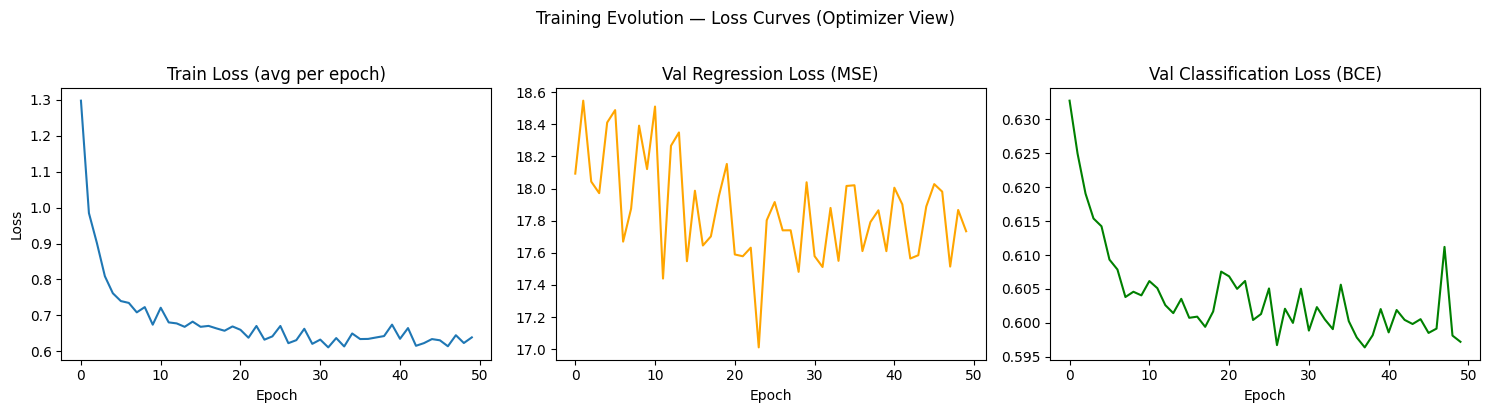

In [23]:
# read the model saved logs from the CSV file and plot for analysis of training and val.
metrics = pd.read_csv("logs/multi_task_admet/version_0/metrics.csv")


# Check Val metrics per epoch 
# Regression: MSE task # Note the MSE is computed with scales vs unscaled targets during training and validation.
# Classification: AUROC per task

# train/loss is logged per step — average per epoch for a clean curve
train_per_epoch = (metrics[["epoch", "train/loss"]]
                   .dropna(subset=["train/loss"])
                   .groupby("epoch")["train/loss"].mean())

# val metrics are logged once per epoch
val = metrics[["epoch", "val/reg_loss", "val/cls_loss"]].dropna(subset=["val/reg_loss"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_per_epoch.index, train_per_epoch.values)
axes[0].set_title("Train Loss (avg per epoch)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(val["epoch"], val["val/reg_loss"], color="orange")
axes[1].set_title("Val Regression Loss (MSE)")
axes[1].set_xlabel("Epoch")

axes[2].plot(val["epoch"], val["val/cls_loss"], color="green")
axes[2].set_title("Val Classification Loss (BCE)")
axes[2].set_xlabel("Epoch")

plt.suptitle("Training Evolution — Loss Curves (Optimizer View)", y=1.02)
plt.tight_layout()
plt.show()


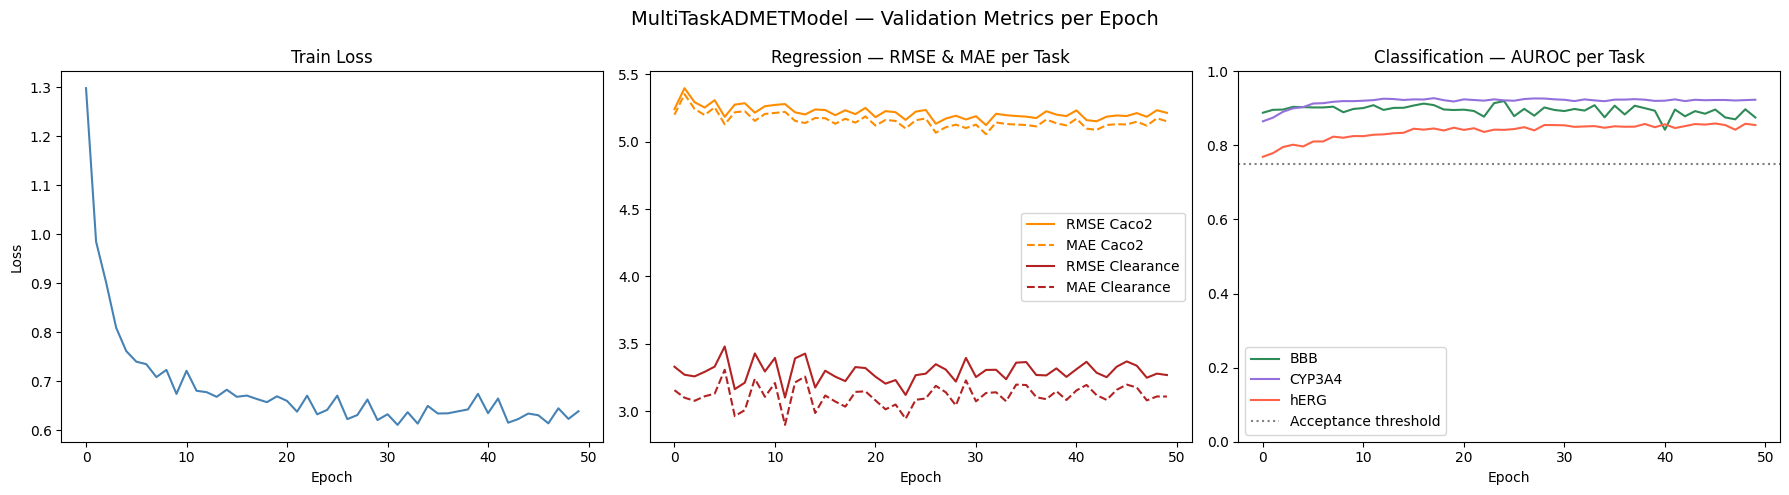

In [24]:
# Load metrics from CSV logs and plot for further analysis of training and validation.
# Check Val metrics per epoch 
# Regression: RMSE and MAE task # Note the RMSE and MAE is computed with scales vs unscaled targets during training and validation.
# Classification: AUROC per task
metrics = pd.read_csv("logs/multi_task_admet/version_0/metrics.csv")

# --- Separate metrics by type ---
train_loss = (metrics[["epoch", "train/loss"]]
              .dropna(subset=["train/loss"])
              .groupby("epoch")["train/loss"].mean())

val_reg = metrics[["epoch", "val/rmse_caco2", "val/mae_caco2",
                    "val/rmse_clearance", "val/mae_clearance"]].dropna(subset=["val/rmse_caco2"])

val_cls = metrics[["epoch", "val/auroc_bbb", "val/auroc_cyp3a4",
                    "val/auroc_herg"]].dropna(subset=["val/auroc_bbb"])

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MultiTaskADMETModel — Validation Metrics per Epoch", fontsize=14)

# Train loss
axes[0].plot(train_loss.index, train_loss.values, color="steelblue")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

# Regression: RMSE + MAE per task
axes[1].plot(val_reg["epoch"], val_reg["val/rmse_caco2"],     label="RMSE Caco2",     color="darkorange")
axes[1].plot(val_reg["epoch"], val_reg["val/mae_caco2"],      label="MAE Caco2",      color="darkorange", linestyle="--")
axes[1].plot(val_reg["epoch"], val_reg["val/rmse_clearance"], label="RMSE Clearance", color="firebrick")
axes[1].plot(val_reg["epoch"], val_reg["val/mae_clearance"],  label="MAE Clearance",  color="firebrick",  linestyle="--")
axes[1].set_title("Regression — RMSE & MAE per Task")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# Classification: AUROC per task
axes[2].plot(val_cls["epoch"], val_cls["val/auroc_bbb"],    label="BBB",    color="seagreen")
axes[2].plot(val_cls["epoch"], val_cls["val/auroc_cyp3a4"], label="CYP3A4", color="mediumpurple")
axes[2].plot(val_cls["epoch"], val_cls["val/auroc_herg"],   label="hERG",   color="tomato")
axes[2].axhline(0.75, color="gray", linestyle=":", label="Acceptance threshold")
axes[2].set_title("Classification — AUROC per Task")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Build function to predict ADMET properties for a given SMILES string using the trained multi-task model.

def predict_admet(smiles: str):
    # Build mol object from SMILES using rdkit.
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES.")
        return
    # process the input molecule to get the same canonical form as the training data, and remove stereochemistry to avoid issues with unseen stereoisomers during inference.
    Chem.RemoveStereochemistry(mol)
    canonical = Chem.MolToSmiles(mol)
    mol_canonical = Chem.MolFromSmiles(canonical)
    # Calculate the same 9 descriptors for the input  molecule as were used in the training data.
    x_d = np.array([[
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
        rdMolDescriptors.CalcNumRings(mol),
        rdMolDescriptors.CalcFractionCSP3(mol),
        Chem.GetFormalCharge(mol)
    ]], dtype=np.float32)
    # scale the descriptors using the same scalers that were fitted on the training data.
    x_d_reg = X_d_scaler_reg.transform(x_d)
    x_d_cls = X_d_scaler_cls.transform(x_d)
    # Build a dataloader for the input molecule and its descriptors to feed into the model for prediction.
    def make_loader(mol, x_d_scaled):
        dp      = cp.data.MoleculeDatapoint(mol=mol, x_d=x_d_scaled[0])
        dataset = cp.data.MoleculeDataset([dp])
        return cp.data.build_dataloader(dataset, batch_size=1, num_workers=0, shuffle=False)
    # Load
    loader_reg = make_loader(mol_canonical, x_d_reg)
    loader_cls = make_loader(mol_canonical, x_d_cls)
    # Model evaluation and prediction for both regression and classification tasks.
    model.eval()
    with torch.no_grad(): # Do not save gradient for backpropagation since we are only doing inference.
        # Regression Inference
        # Use the model class builder for regression and classification heads.
        bmg, V_d, X_d_t, *_ = next(iter(loader_reg))
        reg_preds = model.regression_head(model.encode(bmg, X_d_t)).numpy()[0]
        # Classification Inference
        bmg, V_d, X_d_t, *_ = next(iter(loader_cls))
        cls_probs = model.classification_head(model.encode(bmg, X_d_t)).numpy()[0]


    # Print the predicted ADMET properties in a readable format.
    # For regression tasks, we print the predicted values and also unscale the clearance prediction back to its original scale for better interpretability.
    # For classification tasks, we print the predicted probabilities and also provide an interpretation of whether the
    # molecule is likely to penetrate the BBB, inhibit CYP3A4, or inhibit hERG based on a threshold of 0.5.
    # Note: The interpretation of the classification predictions is based on the assumption that a probability greater than 0.5 indicates a positive prediction for that property (e.g., penetrates BBB, is a CYP3A4 inhibitor, etc.).
    # This threshold can be adjusted based on the specific requirements of the application or based on validation performance.
    print(f"\nSMILES : {canonical}")
    print("\n── Regression ───────────────────────────────────────────")
    print(f"  Caco-2 permeability  (log cm/s) : {reg_preds[0]:+.4f}")
    print(f"  Clearance Hepatocyte (log1p)    : {reg_preds[1]:.4f}  →  {np.expm1(reg_preds[1]):.2f} μL/min/mg")
    print("\n── Classification (probability) ─────────────────────────")
    print(f"  BBB penetration  : {cls_probs[0]:.4f}  {'✓ Penetrates BBB'         if cls_probs[0] > 0.5 else '✗ Does not penetrate BBB'}")
    print(f"  CYP3A4 inhibitor : {cls_probs[1]:.4f}  {'⚠ Inhibitor'              if cls_probs[1] > 0.5 else '✓ Non-inhibitor'}")
    print(f"  hERG inhibitor   : {cls_probs[2]:.4f}  {'⚠ Cardiotoxicity risk'    if cls_probs[2] > 0.5 else '✓ No cardiotoxicity risk'}")

# --- Run: change this SMILES to test any molecule ---
# Change the input SMILES string to test the model's predictions on different molecules. 
# The example provided is for Aspirin, which has known ADMET properties that we can compare against the model's predictions for a sanity check.
#smiles_input = "CC(=O)Oc1ccccc1C(=O)O"  # Aspirin
smiles_input = input ("Enter a SMILES string to predict ADMET properties: ")
predict_admet(smiles_input)



"""
Valor médio Clearance Dataset : 
Valor mediana Clearance Dataset : 
Valor médio Caco2 Dataset: 
Valor mediana Caco2 Dataset: 
"""


SMILES : CC(=O)Oc1ccccc1C(=O)O

── Regression ───────────────────────────────────────────
  Caco-2 permeability  (log cm/s) : -4.6785
  Clearance Hepatocyte (log1p)    : 2.8360  →  16.05 μL/min/mg

── Classification (probability) ─────────────────────────
  BBB penetration  : 0.1151  ✗ Does not penetrate BBB
  CYP3A4 inhibitor : 0.0000  ✓ Non-inhibitor
  hERG inhibitor   : 0.0000  ✓ No cardiotoxicity risk


'\nValor médio Clearance Dataset : \nValor mediana Clearance Dataset : \nValor médio Caco2 Dataset: \nValor mediana Caco2 Dataset: \n'